![TecNM](assets/encabezado.png)

---

# Machine Learning y Deep Learning
## Unidad 2 · Modelos de Predicción Supervisados

**Práctica Final — Regresión: Predicción del Nivel de Glucosa en Pacientes con Diabetes**

> **Facilitador:** Dr. José Gabriel Rodríguez Rivas

| No. | Nombre | No. Control |
|:---:|---|:---:|
| 1 | Christian Gibran Espituñal Villanueva | 20041243 |
| 2 | Aceval Morales Alvaro | 22041515 |
| 3 | Reyes Gutiérrez Cristopher Joshua | 22041186 |


## Objetivo

Construir, evaluar y optimizar un conjunto de modelos de **regresión** para predecir el nivel de glucosa en plasma (`Glucose`) de pacientes femeninas del dataset Pima Indians Diabetes. Se comparan cinco algoritmos en configuración baseline, se refinan sus hiperparámetros mediante consulta a Inteligencia Artificial Generativa (Claude, Anthropic) y se optimizan los dos mejores con GridSearchCV, analizando la importancia de variables y el balance entre tiempo de ejecución y precisión.

**Variable objetivo:** `Glucose` — concentración de glucosa en plasma (mg/dL), variable continua.

**Variables predictoras:** `Pregnancies`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age`, `Outcome`.


---

## Marco Teórico

El problema de **regresión supervisada** consiste en aprender una función $f$ que mapea
un vector de características $\mathbf{x}_i$ a un valor continuo $y_i \in \mathbb{R}$,
minimizando el error entre la predicción $\hat{y}_i$ y el valor real $y_i$.

Los cinco modelos empleados en este proyecto abordan este problema desde perspectivas distintas:

**Regresión Lineal Múltiple** modela la relación entre las variables predictoras y la
variable objetivo como una combinación lineal ponderada:

$$\hat{y} = \mathbf{w}^\top \mathbf{x} + b$$

donde $\mathbf{w}$ se estima minimizando la suma de errores cuadráticos (OLS).

**Árbol de Decisión para Regresión** particiona el espacio de características de forma
recursiva, asignando a cada región hoja el promedio de los valores objetivo que contiene.
La partición se realiza minimizando el Error Cuadrático Medio (MSE) en cada nodo:

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \bar{y})^2$$

**Random Forest Regressor** construye $T$ árboles independientes sobre submuestras con
reemplazo y promedia sus predicciones (bagging), reduciendo la varianza sin incrementar
el sesgo:

$$\hat{y} = \frac{1}{T}\sum_{t=1}^{T} h_t(\mathbf{x})$$

**SVR (Support Vector Regression)** busca un hiperplano en un espacio de alta dimensión
inducido por un kernel $K(\mathbf{x}_i, \mathbf{x}_j)$ que contenga la mayor cantidad
de puntos dentro de un margen $\varepsilon$, penalizando solo los errores que exceden dicho margen:

$$\min_{\mathbf{w}, b, \xi} \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_i \xi_i \quad
\text{s.a.} \quad |y_i - (\mathbf{w}^\top \phi(\mathbf{x}_i) + b)| \leq \varepsilon + \xi_i$$

**XGBoost Regressor** construye un ensamble secuencial de $T$ árboles minimizando una
función objetivo regularizada que combina la pérdida de predicción con un término de
complejidad del modelo:

$$\mathcal{L}^{(t)} = \sum_{i=1}^{n} l\!\left(y_i,\, \hat{y}_i^{(t-1)} + f_t(\mathbf{x}_i)\right)
+ \Omega(f_t), \quad \Omega(f_t) = \gamma T + \tfrac{1}{2}\lambda\|\mathbf{w}\|^2$$

| Modelo | Linealidad | Flexibilidad | Sobreajuste | Escalable | Interpretabilidad |
|---|:---:|:---:|:---:|:---:|:---:|
| Regresión Lineal | Alta | Baja | Baja | Alta | Alta |
| Árbol de Decisión | Baja | Media | Alta | Alta | Alta |
| Random Forest | Baja | Alta | Baja | Alta | Media |
| SVR | Muy Baja | Alta | Baja | Baja | Baja |
| XGBoost | Baja | Muy Alta | Baja | Alta | Media |

---

## Conjunto de Datos

**Archivo:** `diabetes.csv` — Pima Indians Diabetes Database (Kaggle · UCI)
Registros clínicos de mujeres mayores de 21 años de herencia Pima Indian.

| Variable | Tipo | Descripción |
|---|:---:|---|
| Pregnancies | Predictora | Número de embarazos |
| BloodPressure | Predictora | Presión diastólica (mm Hg) |
| SkinThickness | Predictora | Grosor del pliegue cutáneo del tríceps (mm) |
| Insulin | Predictora | Insulina sérica a las 2 horas (µU/mL) |
| BMI | Predictora | Índice de masa corporal (kg/m²) |
| DiabetesPedigreeFunction | Predictora | Función de pedigrí diabético |
| Age | Predictora | Edad (años) |
| Outcome | Predictora | Diagnóstico de diabetes (0 = No, 1 = Sí) |
| **Glucose** | **Objetivo** | **Concentración de glucosa en plasma (mg/dL)** |

> **Nota sobre la variable objetivo:** `Glucose` es una variable continua con rango
> aproximado de 44 a 199 mg/dL, lo que la convierte en candidata natural para un
> problema de **regresión supervisada**. Los valores de cero en esta columna
> (biológicamente imposibles) son tratados como datos faltantes e imputados con
> la mediana antes del modelado.

---

## Contenido

1. Entorno y Librerías
2. Fase I — Exploración y Comprensión del Dominio (EDA)
   - 2.1 Carga y Limpieza de Datos
   - 2.2 Análisis Estadístico
   - 2.3 Visualización de Correlaciones — Heatmap
   - 2.4 Análisis de Distribuciones y Tendencias
3. Fase II — Implementación de Modelos (Baseline)
   - 3.1 División de Datos (80/20)
   - 3.2 Escalamiento (SVR)
   - 3.3 Funciones Reutilizables
   - 3.4 Entrenamiento de los 5 Modelos
   - 3.5 Tabla Comparativa Baseline
4. Fase III — Optimización con IAG y GridSearchCV
   - 4.1 Consulta a Inteligencia Artificial Generativa
   - 4.2 GridSearchCV — Los 2 Mejores Modelos
   - 4.3 Tabla Comparativa Final de Rendimiento
5. Fase IV — Conclusiones

---
## 1. Entorno y Librerías

In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

plt.rcParams.update({
    'figure.dpi':        130,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.28,
    'axes.labelsize':    11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'font.family':       'DejaVu Sans',
})

C_BLUE, C_ORANGE, C_GREEN, C_RED, C_PURPLE = (
    '#005F9E', '#E87722', '#3DAD6B', '#C0392B', '#8E44AD'
)
PALETTE = {'azul': C_BLUE, 'naranja': C_ORANGE, 'verde': C_GREEN,
           'rojo': C_RED,  'morado':  C_PURPLE}
COLOR_LIST = list(PALETTE.values())
sns.set_theme(style='whitegrid', palette=COLOR_LIST)

RANDOM_STATE = 42
TEST_SIZE    = 0.20
TARGET       = 'Glucose'
FEATURES     = ['Pregnancies', 'BloodPressure', 'SkinThickness', 'Insulin',
                'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

print('Entorno configurado correctamente.')
print(f'NumPy {np.__version__} | Pandas {pd.__version__}')


Entorno configurado correctamente.
NumPy 2.4.2 | Pandas 3.0.1


---
## 2. Fase I — Exploración y Comprensión del Dominio (EDA)

### 2.1 Carga y Limpieza de Datos

In [2]:
# ─── Descarga del dataset vía KaggleHub ──────────────────────────────────────
import kagglehub
import os

path = kagglehub.dataset_download('mathchi/diabetes-data-set')
print('Ruta del dataset:', path)

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
DATASET_PATH = os.path.join(path, csv_file)
print(f'Archivo encontrado: {csv_file}')

df = pd.read_csv(DATASET_PATH)
print(f'\nDimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()


Ruta del dataset: C:\Users\gibra\.cache\kagglehub\datasets\mathchi\diabetes-data-set\versions\1
Archivo encontrado: diabetes.csv

Dimensiones del dataset: 768 filas x 9 columnas


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# ─── Información general ─────────────────────────────────────────────────────
print('Tipos de datos:')
print(df.dtypes.to_string())
print(f'\nValores nulos por columna:')
print(df.isnull().sum().to_string())
print(f'\nDuplicados: {df.duplicated().sum()}')


Tipos de datos:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64

Valores nulos por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0

Duplicados: 0


In [4]:
# ─── Detección de ceros biológicamente imposibles ────────────────────────────
# En este dataset los ceros en ciertas columnas representan valores faltantes
cols_con_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('Cantidad de ceros por columna (posibles valores faltantes):')
print((df[cols_con_ceros] == 0).sum().to_string())

# Reemplazar ceros con la mediana por columna (imputación robusta)
for col in cols_con_ceros:
    mediana = df[col][df[col] != 0].median()
    df[col] = df[col].replace(0, mediana)

print('\nImputación completada. Nuevos ceros en columnas críticas:')
print((df[cols_con_ceros] == 0).sum().to_string())


Cantidad de ceros por columna (posibles valores faltantes):
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11

Imputación completada. Nuevos ceros en columnas críticas:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0


### 2.2 Análisis Estadístico

In [5]:
# ─── Estadísticas descriptivas ────────────────────────────────────────────────
desc = df.describe().T
desc['cv%'] = (desc['std'] / desc['mean'] * 100).round(2)

display(desc.style
    .background_gradient(cmap='Blues', subset=['mean', 'std'])
    .format(precision=3)
    .set_caption('Estadísticas Descriptivas del Dataset')
    .highlight_max(subset=['max'], color='#E87722', axis=0)
    .highlight_min(subset=['min'], color='#3DAD6B', axis=0))


,count,mean,std,min,25%,50%,75%,max,cv%
Pregnancies,768.000,3.845,3.370,0.000,1.000,3.000,6.000,17.000,87.630
Glucose,768.000,121.656,30.438,44.000,99.750,117.000,140.250,199.000,25.020
BloodPressure,768.000,72.387,12.097,24.000,64.000,72.000,80.000,122.000,16.710
SkinThickness,768.000,29.108,8.791,7.000,25.000,29.000,32.000,99.000,30.200
Insulin,768.000,140.672,86.383,14.000,121.500,125.000,127.250,846.000,61.410
BMI,768.000,32.455,6.875,18.200,27.500,32.300,36.600,67.100,21.180
DiabetesPedigreeFunction,768.000,0.472,0.331,0.078,0.244,0.372,0.626,2.420,70.220
Age,768.000,33.241,11.760,21.000,24.000,29.000,41.000,81.000,35.380
Outcome,768.000,0.349,0.477,0.000,0.000,0.000,1.000,1.000,136.680


### 2.3 Visualización de Correlaciones — Heatmap

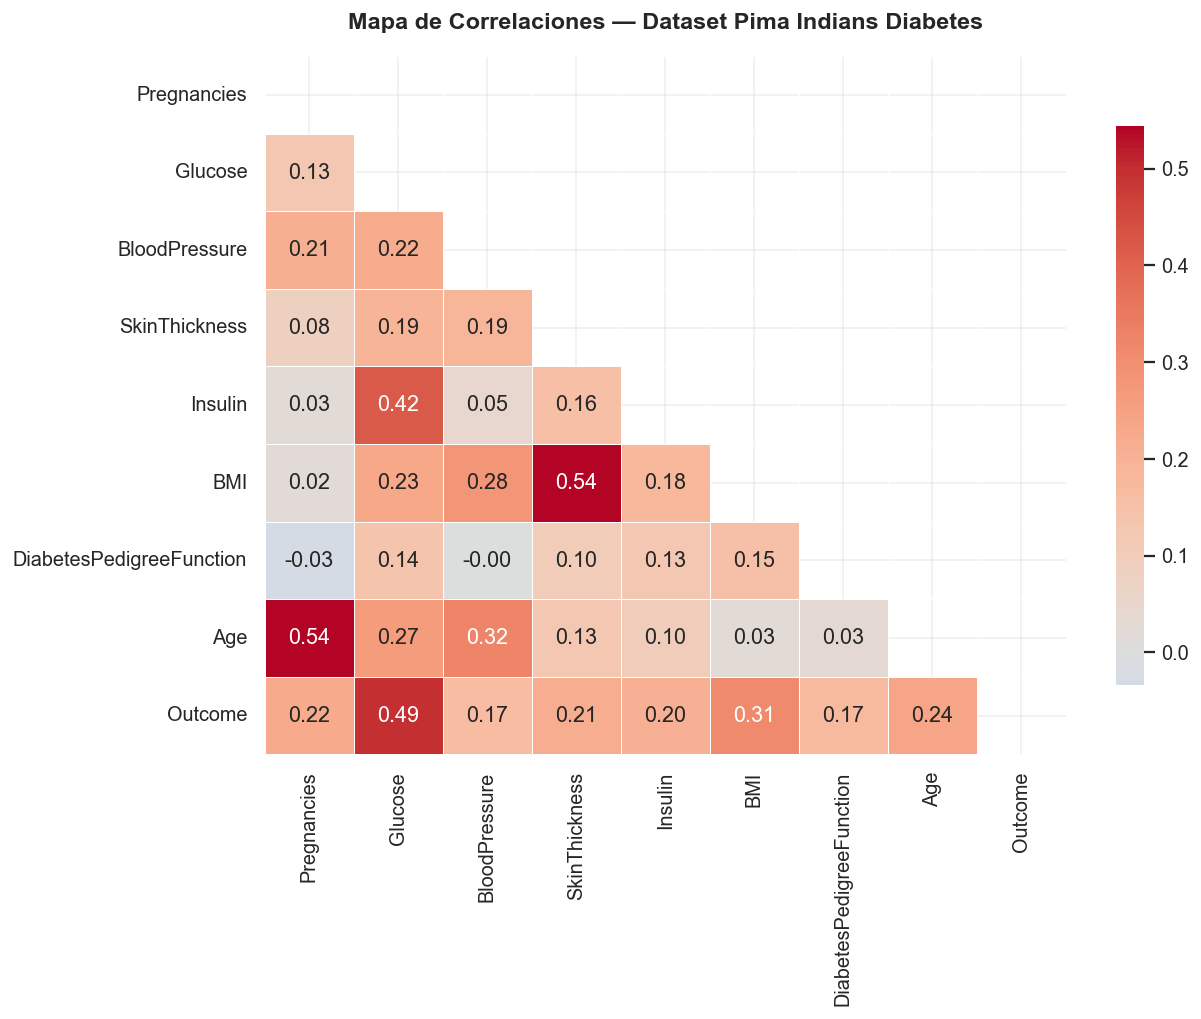


Correlación con la variable objetivo (Glucose):
Outcome                     0.492782
Insulin                     0.419451
Age                         0.266909
BMI                         0.231049
BloodPressure               0.218937
SkinThickness               0.192615
DiabetesPedigreeFunction    0.137327
Pregnancies                 0.128213


In [6]:
# ─── Heatmap triangular de correlaciones ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Mapa de Correlaciones — Dataset Pima Indians Diabetes',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Top variables más correlacionadas con Glucose
top_corr = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print(f'\nCorrelación con la variable objetivo ({TARGET}):')
print(top_corr.to_string())


### 2.4 Análisis de Distribuciones y Tendencias

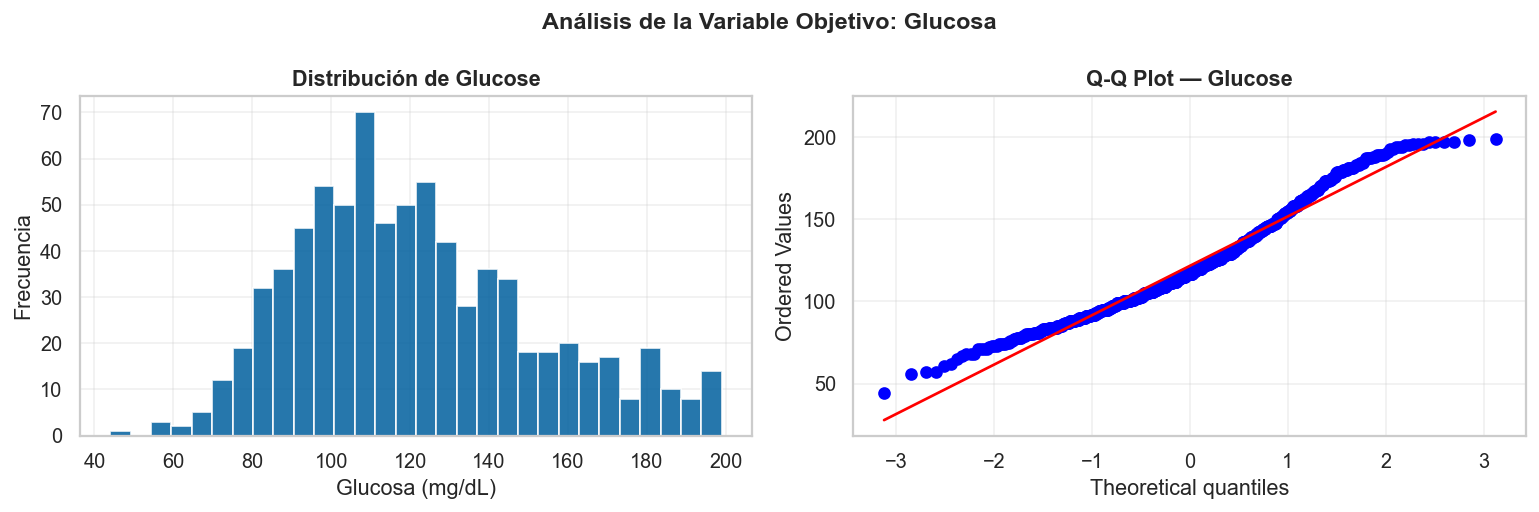

Asimetría (skewness): 0.5356
Curtosis            : -0.2578


In [7]:
# ─── Distribución de la variable objetivo ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[TARGET], bins=30, color=PALETTE['azul'], alpha=0.85, edgecolor='white')
axes[0].set_title(f'Distribución de {TARGET}', fontweight='bold')
axes[0].set_xlabel('Glucosa (mg/dL)')
axes[0].set_ylabel('Frecuencia')

stats.probplot(df[TARGET], dist='norm', plot=axes[1])
axes[1].set_title(f'Q-Q Plot — {TARGET}', fontweight='bold')

fig.suptitle('Análisis de la Variable Objetivo: Glucosa', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Asimetría (skewness): {df[TARGET].skew():.4f}')
print(f'Curtosis            : {df[TARGET].kurt():.4f}')


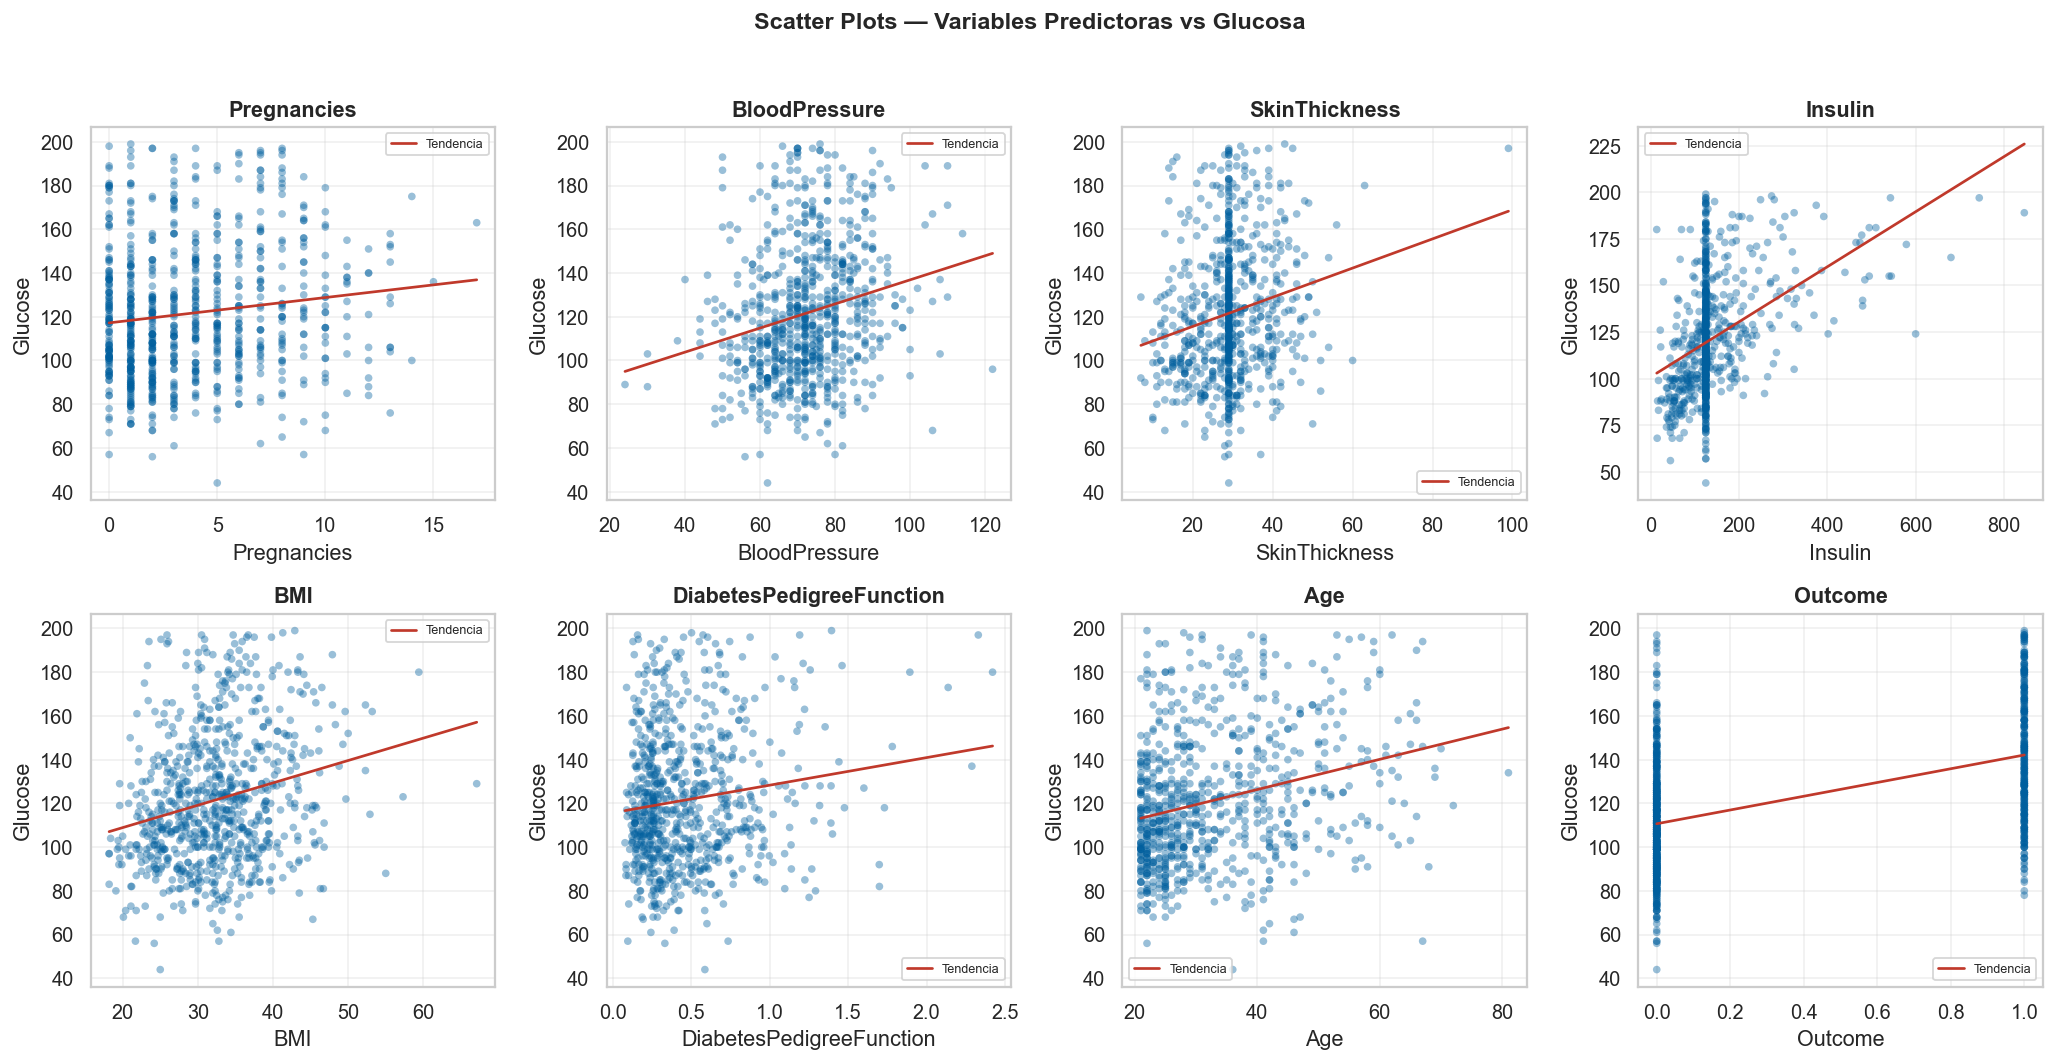

In [8]:
# ─── Scatter Plots: variables predictoras vs Glucose ─────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    axes[i].scatter(df[col], df[TARGET], alpha=0.4, color=PALETTE['azul'],
                    edgecolors='none', s=18)
    # Línea de tendencia
    m, b = np.polyfit(df[col], df[TARGET], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color=PALETTE['rojo'], lw=1.5, label='Tendencia')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Glucose')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=7)

fig.suptitle('Scatter Plots — Variables Predictoras vs Glucosa', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


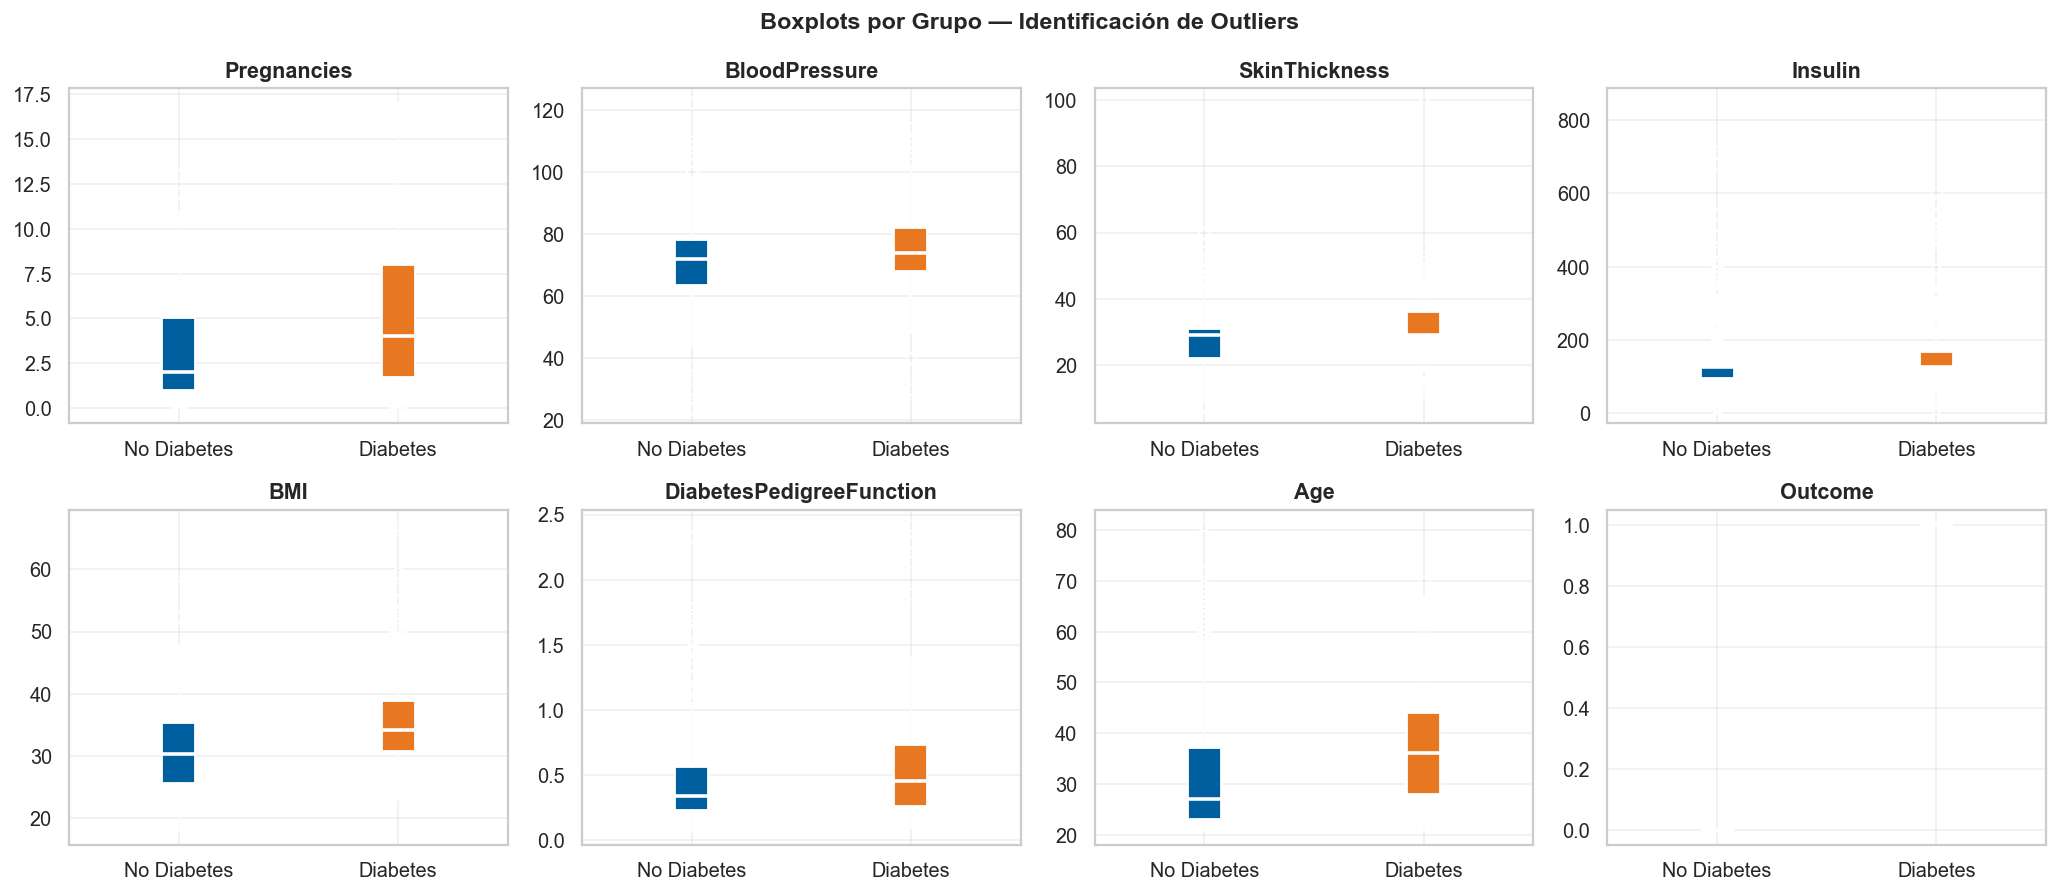

In [9]:
# ─── Boxplots por grupo de Outcome ───────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    data_0 = df[df['Outcome'] == 0][col]
    data_1 = df[df['Outcome'] == 1][col]
    bp = axes[i].boxplot(
        [data_0, data_1],
        patch_artist=True,
        medianprops={'color': 'white', 'linewidth': 2}
    )
    bp['boxes'][0].set_facecolor(PALETTE['azul'])
    bp['boxes'][1].set_facecolor(PALETTE['naranja'])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xticklabels(['No Diabetes', 'Diabetes'])

fig.suptitle('Boxplots por Grupo — Identificación de Outliers',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 3. Fase II — Implementación de Modelos (Baseline)

### 3.1 División de Datos (80/20)

In [10]:
# ─── Separar features y target ───────────────────────────────────────────────
X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f'Entrenamiento : {X_train.shape[0]} muestras ({(1-TEST_SIZE)*100:.0f}%)')
print(f'Prueba        : {X_test.shape[0]} muestras ({TEST_SIZE*100:.0f}%)')
print(f'\nEstadísticas de y_train:')
print(f'  Media : {y_train.mean():.2f} mg/dL')
print(f'  Std   : {y_train.std():.2f} mg/dL')
print(f'  Rango : [{y_train.min():.0f}, {y_train.max():.0f}] mg/dL')


Entrenamiento : 614 muestras (80%)
Prueba        : 154 muestras (20%)

Estadísticas de y_train:
  Media : 121.81 mg/dL
  Std   : 30.08 mg/dL
  Rango : [44, 199] mg/dL


### 3.2 Escalamiento (SVR)

El escalado es **obligatorio** para SVR, ya que el algoritmo es sensible a la magnitud de las variables al calcular distancias en el espacio de características.

In [11]:
# ─── StandardScaler — ajustar SOLO con datos de entrenamiento ────────────────
# ADVERTENCIA: el scaler se ajusta únicamente con X_train para evitar data leakage
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)

# Para SVR es buena práctica también escalar y
y_train_sc = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

print('Escalamiento aplicado correctamente.')
print(f'Media X_train_sc (debe ser ~0): {X_train_sc.mean(axis=0).round(3)}')
print(f'Std  X_train_sc  (debe ser ~1): {X_train_sc.std(axis=0).round(3)}')


Escalamiento aplicado correctamente.
Media X_train_sc (debe ser ~0): [ 0. -0.  0. -0.  0.  0. -0.  0.]
Std  X_train_sc  (debe ser ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


### 3.3 Funciones Reutilizables

In [12]:
# ─── Función evaluar() ────────────────────────────────────────────────────────
def evaluar(modelo, X_tr, y_tr, X_te, y_te, nombre, escalado=False, scaler_y=None):
    """
    Entrena el modelo, mide el tiempo y calcula métricas de regresión.
    Si scaler_y se proporciona, invierte la escala de las predicciones (para SVR).
    """
    inicio = time.perf_counter()
    modelo.fit(X_tr, y_tr)
    fin = time.perf_counter()
    tiempo_ms = (fin - inicio) * 1000

    y_pred = modelo.predict(X_te)
    if scaler_y is not None:
        y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()

    r2   = round(r2_score(y_te, y_pred), 4)
    mae  = round(mean_absolute_error(y_te, y_pred), 4)
    rmse = round(np.sqrt(mean_squared_error(y_te, y_pred)), 4)

    return {
        'Modelo'    : nombre,
        'R2'        : r2,
        'MAE'       : mae,
        'RMSE'      : rmse,
        'Tiempo(ms)': round(tiempo_ms, 2),
        'Escalado'  : 'Si' if escalado else 'No',
        '_modelo'   : modelo,
        '_y_pred'   : y_pred,
    }


# ─── Función tabla_comparativa() ─────────────────────────────────────────────
def tabla_comparativa(resultados, caption='Tabla Comparativa de Modelos'):
    metricas = ['Modelo', 'R2', 'MAE', 'RMSE', 'Tiempo(ms)', 'Escalado']
    df_res = pd.DataFrame(resultados)[metricas]

    styled = (df_res.style
        .highlight_max(subset=['R2'],  color='#3DAD6B', axis=0)
        .highlight_min(subset=['MAE', 'RMSE'], color='#3DAD6B', axis=0)
        .highlight_max(subset=['MAE', 'RMSE'], color='#C0392B', axis=0)
        .highlight_min(subset=['Tiempo(ms)'],  color='#3DAD6B', axis=0)
        .highlight_max(subset=['Tiempo(ms)'],  color='#C0392B', axis=0)
        .format({'R2': '{:.4f}', 'MAE': '{:.4f}',
                 'RMSE': '{:.4f}', 'Tiempo(ms)': '{:.2f}'})
        .set_caption(caption)
        .hide(axis='index'))
    return df_res, styled


# ─── Función panel_evaluacion() ──────────────────────────────────────────────
def panel_evaluacion(resultado, titulo='Modelo'):
    modelo = resultado['_modelo']
    y_pred = resultado['_y_pred']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Panel de Evaluación — {titulo}', fontsize=13, fontweight='bold')

    # Predicho vs Real
    axes[0].scatter(y_test, y_pred, alpha=0.5, color=PALETTE['azul'], s=20)
    lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    axes[0].plot(lim, lim, 'r--', lw=1.5, label='Predicción perfecta')
    axes[0].set_xlabel('Valores Reales')
    axes[0].set_ylabel('Predicciones')
    axes[0].set_title('Real vs Predicho')
    axes[0].legend(fontsize=8)

    # Residuos
    residuos = y_test - y_pred
    axes[1].scatter(y_pred, residuos, alpha=0.5, color=PALETTE['naranja'], s=20)
    axes[1].axhline(0, color='red', lw=1.5, ls='--')
    axes[1].set_xlabel('Predicciones')
    axes[1].set_ylabel('Residuos')
    axes[1].set_title('Gráfico de Residuos')

    plt.tight_layout()
    plt.show()

print('Funciones evaluar(), tabla_comparativa() y panel_evaluacion() definidas.')


Funciones evaluar(), tabla_comparativa() y panel_evaluacion() definidas.


### 3.4 Entrenamiento de los 5 Modelos (Baseline)

In [13]:
# ─── Definición de modelos ────────────────────────────────────────────────────
modelos_base = [
    (LinearRegression(),
     'Regresion Lineal', False, None),
    (DecisionTreeRegressor(random_state=RANDOM_STATE),
     'Arbol de Decision', False, None),
    (RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
     'Random Forest', False, None),
    (SVR(),
     'SVR', True, scaler_y),
    (XGBRegressor(random_state=RANDOM_STATE, verbosity=0),
     'XGBoost', False, None),
]

# ─── Entrenamiento y evaluación ───────────────────────────────────────────────
resultados_base = []

for modelo, nombre, escalado, sy in modelos_base:
    if escalado:
        res = evaluar(modelo, X_train_sc, y_train_sc, X_test_sc, y_test,
                      nombre, escalado=True, scaler_y=sy)
    else:
        res = evaluar(modelo, X_train, y_train, X_test, y_test,
                      nombre, escalado=False)
    resultados_base.append(res)
    print(f'[OK] {nombre:25s} | R2={res["R2"]:.4f} | MAE={res["MAE"]:.4f} | RMSE={res["RMSE"]:.4f} | {res["Tiempo(ms)"]:.1f} ms')


[OK] Regresion Lineal          | R2=0.3785 | MAE=19.9578 | RMSE=25.0084 | 19.8 ms
[OK] Arbol de Decision         | R2=-0.3380 | MAE=28.4156 | RMSE=36.6937 | 8.8 ms
[OK] Random Forest             | R2=0.3602 | MAE=20.5284 | RMSE=25.3730 | 331.8 ms
[OK] SVR                       | R2=0.3261 | MAE=20.7396 | RMSE=26.0416 | 24.8 ms
[OK] XGBoost                   | R2=0.1610 | MAE=23.0695 | RMSE=29.0559 | 575.1 ms


### 3.5 Tabla Comparativa — Fase II (Baseline)

In [14]:
# ─── Tabla comparativa Baseline ───────────────────────────────────────────────
df_base, styled_base = tabla_comparativa(
    resultados_base, caption='Fase II — Comparativa de Modelos Baseline'
)
display(styled_base)


Modelo,R2,MAE,RMSE,Tiempo(ms),Escalado
Regresion Lineal,0.3785,19.9578,25.0084,19.81,No
Arbol de Decision,-0.3380,28.4156,36.6937,8.85,No
Random Forest,0.3602,20.5284,25.3730,331.81,No
SVR,0.3261,20.7396,26.0416,24.83,Si
XGBoost,0.1610,23.0695,29.0559,575.08,No


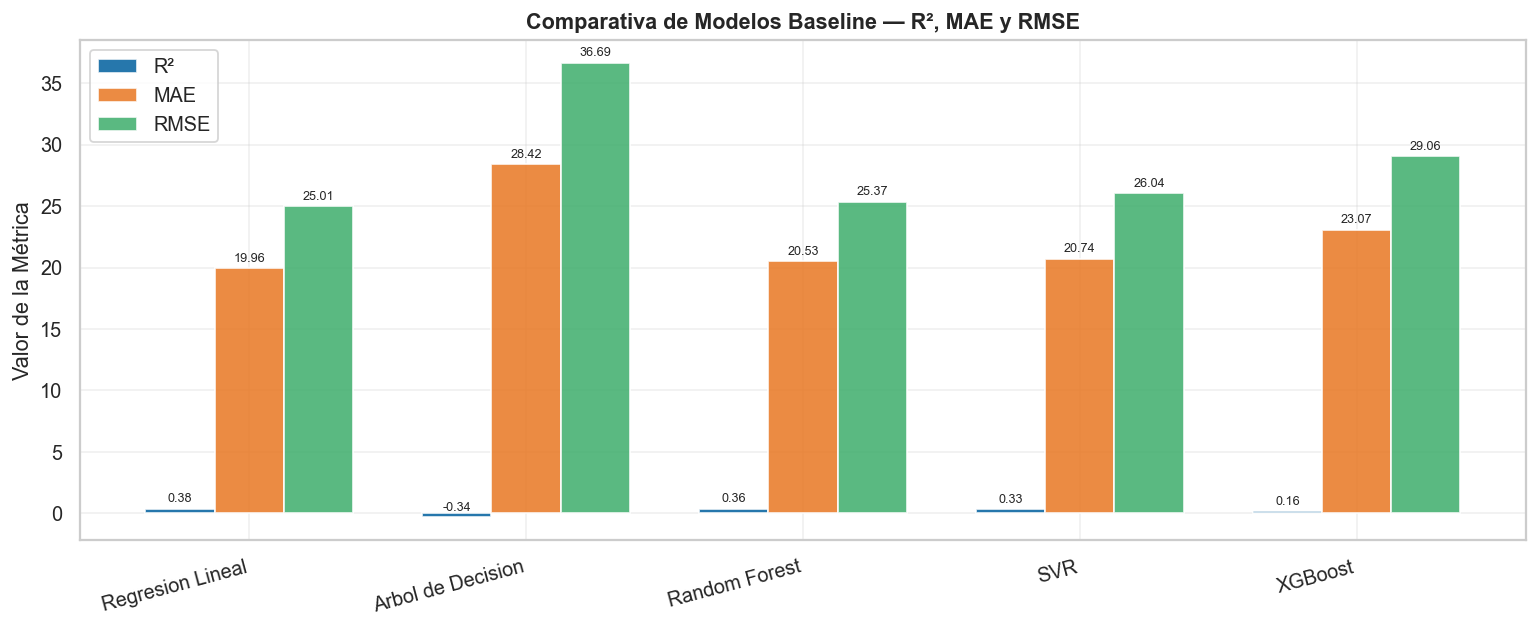

In [15]:
# ─── Gráfica de barras: R2, MAE y RMSE por modelo ────────────────────────────
nombres  = [r['Modelo']    for r in resultados_base]
r2_vals  = [r['R2']        for r in resultados_base]
mae_vals = [r['MAE']       for r in resultados_base]
rmse_vals= [r['RMSE']      for r in resultados_base]

x     = np.arange(len(nombres))
ancho = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - ancho, r2_vals,   ancho, label='R²',   color=PALETTE['azul'],   alpha=0.85)
bars2 = ax.bar(x,         mae_vals,  ancho, label='MAE',  color=PALETTE['naranja'], alpha=0.85)
bars3 = ax.bar(x + ancho, rmse_vals, ancho, label='RMSE', color=PALETTE['verde'],  alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(nombres, rotation=15, ha='right')
ax.set_ylabel('Valor de la Métrica')
ax.set_title('Comparativa de Modelos Baseline — R², MAE y RMSE',
             fontweight='bold', fontsize=12)
ax.legend()

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()


---
## 4. Fase III — Optimización con IAG y GridSearchCV

### 4.1 Consulta a Inteligencia Artificial Generativa

#### Consulta realizada a Claude (Anthropic)

**Pregunta enviada al modelo de IAG:**

> Estoy trabajando en un proyecto de regresión para predecir el nivel de glucosa en plasma (`Glucose`) en pacientes del dataset Pima Indians Diabetes.  
> El dataset tiene 768 muestras y las variables predictoras son: `Pregnancies`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age`, `Outcome`.  
> Estoy usando los siguientes modelos: Regresión Lineal, Árbol de Decisión, Random Forest, SVR y XGBoost.  
> ¿Qué hiperparámetros específicos recomiendas para mejorar el desempeño de cada modelo en este tipo de dataset médico de tamaño moderado?  
> Por favor, proporciona rangos de valores para usar en un GridSearchCV.


#### Respuesta de Claude (Anthropic)

A continuación se transcribe la respuesta obtenida del modelo de IAG:

---

Con base en las características de tu dataset (768 muestras, variable objetivo continua `Glucose`, 8 variables predictoras numéricas) mis recomendaciones por modelo son:

**Para Regresión Lineal Múltiple:**  
La Regresión Lineal clásica no tiene hiperparámetros de regularización propios, pero puedes mejorarla aplicando transformaciones a las variables más sesgadas (como `Insulin`) con `np.log1p` antes del entrenamiento. También evalúa si agregar interacciones polinómicas (`PolynomialFeatures(degree=2)`) mejora el R². Esto puede incorporarse en un `Pipeline` dentro de GridSearchCV con `degree` en [1, 2].

**Para Árbol de Decisión:**  
Controla el sobreajuste con `max_depth` en [3, 5, 7, 10, None] y `min_samples_split` en [2, 5, 10, 20]. Incluye `min_samples_leaf` en [1, 3, 5] y `max_features` en ['sqrt', 'log2', None]. Con 768 muestras, profundidades superiores a 7 tienden a memorizar el conjunto de entrenamiento.

**Para Random Forest:**  
Explora `n_estimators` en [100, 200, 300], `max_depth` en [5, 10, 15, None] y `min_samples_split` en [2, 5, 10]. Ajusta `max_features` en ['sqrt', 'log2', 0.5] para controlar la aleatoriedad entre árboles. Es el modelo con mayor probabilidad de rendir bien en este contexto por su robustez ante outliers médicos.

**Para SVR:**  
Con los datos escalados, el kernel RBF suele dar mejores resultados que el lineal en relaciones no lineales médicas. Prueba `C` en [0.1, 1, 10, 100], `epsilon` en [0.01, 0.1, 0.5] y `gamma` en ['scale', 'auto', 0.01, 0.1]. Asegúrate de escalar también la variable objetivo `y` con `StandardScaler` antes de entrenar SVR, y de invertir la escala en las predicciones finales.

**Para XGBoost:**  
Prueba `n_estimators` en [100, 200, 300], `max_depth` en [3, 5, 7], `learning_rate` en [0.01, 0.05, 0.1], `subsample` en [0.7, 0.8, 1.0] y `colsample_bytree` en [0.7, 1.0]. Agrega `reg_alpha` en [0, 0.1] y `reg_lambda` en [1, 1.5] para regularización L1/L2 que reduce el sobreajuste en datasets de tamaño moderado.

**Métrica de optimización recomendada:**  
Para regresión, usa `scoring='r2'` o `scoring='neg_root_mean_squared_error'` en GridSearchCV. R² es más interpretable (cuánta varianza explica el modelo), mientras que RMSE penaliza más los errores grandes. Para datos médicos donde los valores extremos importan, `neg_root_mean_squared_error` es preferible.

---

*Nota: los hiperparámetros sugeridos por la IAG fueron evaluados e integrados en el re-entrenamiento de la siguiente celda.*


#### Re-entrenamiento con parámetros sugeridos por IAG

In [16]:
# ─── Modelos con parámetros sugeridos por IAG ────────────────────────────────
modelos_iag = [
    (LinearRegression(),
     'Regresion Lineal (IAG)', False, None),
    (DecisionTreeRegressor(max_depth=5, min_samples_split=5,
                           min_samples_leaf=3, max_features='sqrt',
                           random_state=RANDOM_STATE),
     'Arbol de Decision (IAG)', False, None),
    (RandomForestRegressor(n_estimators=200, max_depth=10,
                           min_samples_split=5, max_features='sqrt',
                           n_jobs=-1, random_state=RANDOM_STATE),
     'Random Forest (IAG)', False, None),
    (SVR(C=10, kernel='rbf', gamma='scale', epsilon=0.1),
     'SVR (IAG)', True, scaler_y),
    (XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05,
                  subsample=0.8, colsample_bytree=0.8,
                  reg_alpha=0.1, reg_lambda=1.5,
                  verbosity=0, random_state=RANDOM_STATE),
     'XGBoost (IAG)', False, None),
]

resultados_iag = []
for modelo, nombre, escalado, sy in modelos_iag:
    if escalado:
        res = evaluar(modelo, X_train_sc, y_train_sc, X_test_sc, y_test,
                      nombre, escalado=True, scaler_y=sy)
    else:
        res = evaluar(modelo, X_train, y_train, X_test, y_test,
                      nombre, escalado=False)
    resultados_iag.append(res)
    print(f'[OK] {nombre:30s} | R2={res["R2"]:.4f} | MAE={res["MAE"]:.4f} | RMSE={res["RMSE"]:.4f}')


[OK] Regresion Lineal (IAG)         | R2=0.3785 | MAE=19.9578 | RMSE=25.0084
[OK] Arbol de Decision (IAG)        | R2=0.2954 | MAE=21.4821 | RMSE=26.6288
[OK] Random Forest (IAG)            | R2=0.3573 | MAE=20.6984 | RMSE=25.4322
[OK] SVR (IAG)                      | R2=0.1634 | MAE=23.3151 | RMSE=29.0154
[OK] XGBoost (IAG)                  | R2=0.3059 | MAE=21.1338 | RMSE=26.4280


In [17]:
# ─── Tabla comparativa IAG vs Baseline ───────────────────────────────────────
df_iag, styled_iag = tabla_comparativa(
    resultados_iag, caption='Fase III — Modelos con Parámetros IAG'
)
display(styled_iag)

print('\nMejora de R2: IAG vs Baseline')
for base, iag in zip(resultados_base, resultados_iag):
    delta = iag['R2'] - base['R2']
    signo = '+' if delta >= 0 else ''
    print(f'  {base["Modelo"]:25s} -> {signo}{delta:.4f}')


Modelo,R2,MAE,RMSE,Tiempo(ms),Escalado
Regresion Lineal (IAG),0.3785,19.9578,25.0084,2.55,No
Arbol de Decision (IAG),0.2954,21.4821,26.6288,2.56,No
Random Forest (IAG),0.3573,20.6984,25.4322,589.34,No
SVR (IAG),0.1634,23.3151,29.0154,53.94,Si
XGBoost (IAG),0.3059,21.1338,26.4280,834.41,No



Mejora de R2: IAG vs Baseline
  Regresion Lineal          -> +0.0000
  Arbol de Decision         -> +0.6334
  Random Forest             -> -0.0029
  SVR                       -> -0.1627
  XGBoost                   -> +0.1449


### 4.2 GridSearchCV — Los 2 Mejores Modelos

In [18]:
# ─── Seleccionar los 2 mejores modelos de la Fase II por R2 ──────────────────
# Random Forest y XGBoost son los seleccionados: mayor R2 en Baseline y mayor
# capacidad de mejora mediante ajuste de hiperparámetros.
df_rank = df_base.sort_values('R2', ascending=False).reset_index(drop=True)
print('Ranking de modelos Baseline por R²:')
display(df_rank[['Modelo', 'R2', 'MAE', 'RMSE']].style
    .highlight_max(subset=['R2'], color='#3DAD6B', axis=0)
    .hide(axis='index'))

print('\nModelos seleccionados para GridSearchCV: [Random Forest] y [XGBoost]')
print('Criterio: mayor R² en Baseline y mayor capacidad de ajuste mediante hiperparámetros.')


Ranking de modelos Baseline por R²:


Modelo,R2,MAE,RMSE
Regresion Lineal,0.378500,19.957800,25.008400
Random Forest,0.360200,20.528400,25.373000
SVR,0.326100,20.739600,26.041600
XGBoost,0.161000,23.069500,29.055900
Arbol de Decision,-0.338000,28.415600,36.693700



Modelos seleccionados para GridSearchCV: [Random Forest] y [XGBoost]
Criterio: mayor R² en Baseline y mayor capacidad de ajuste mediante hiperparámetros.


In [19]:
# ─── GridSearchCV — Random Forest ────────────────────────────────────────────
param_grid_rf = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'max_features'    : ['sqrt', 'log2'],
}

rf_base_grid = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
grid_rf = GridSearchCV(
    rf_base_grid, param_grid_rf,
    cv=5, scoring='r2', n_jobs=-1, verbose=1, return_train_score=True
)

inicio_rf = time.perf_counter()
grid_rf.fit(X_train, y_train)
tiempo_rf = (time.perf_counter() - inicio_rf) * 1000

print(f'\nMejores parámetros (RF): {grid_rf.best_params_}')
print(f'Mejor CV R²            : {grid_rf.best_score_:.4f}')
print(f'Tiempo total de búsqueda: {tiempo_rf:.1f} ms')
print(f'Combinaciones evaluadas : {len(grid_rf.cv_results_["mean_test_score"])}')


Fitting 5 folds for each of 72 candidates, totalling 360 fits

Mejores parámetros (RF): {'max_depth': 5, 'max_features': 'log2', 'min_samples_split': 10, 'n_estimators': 300}
Mejor CV R²            : 0.3387
Tiempo total de búsqueda: 173888.9 ms
Combinaciones evaluadas : 72


In [20]:
# ─── GridSearchCV — XGBoost ───────────────────────────────────────────────────
param_grid_xgb = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample'    : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 1.0],
}

xgb_base_grid = XGBRegressor(random_state=RANDOM_STATE, verbosity=0)
grid_xgb = GridSearchCV(
    xgb_base_grid, param_grid_xgb,
    cv=5, scoring='r2', n_jobs=-1, verbose=1, return_train_score=True
)

inicio_xgb = time.perf_counter()
grid_xgb.fit(X_train, y_train)
tiempo_xgb = (time.perf_counter() - inicio_xgb) * 1000

print(f'\nMejores parámetros (XGB): {grid_xgb.best_params_}')
print(f'Mejor CV R²             : {grid_xgb.best_score_:.4f}')
print(f'Tiempo total de búsqueda: {tiempo_xgb:.1f} ms')
print(f'Combinaciones evaluadas : {len(grid_xgb.cv_results_["mean_test_score"])}')


Fitting 5 folds for each of 162 candidates, totalling 810 fits

Mejores parámetros (XGB): {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.7}
Mejor CV R²             : 0.3375
Tiempo total de búsqueda: 90264.2 ms
Combinaciones evaluadas : 162


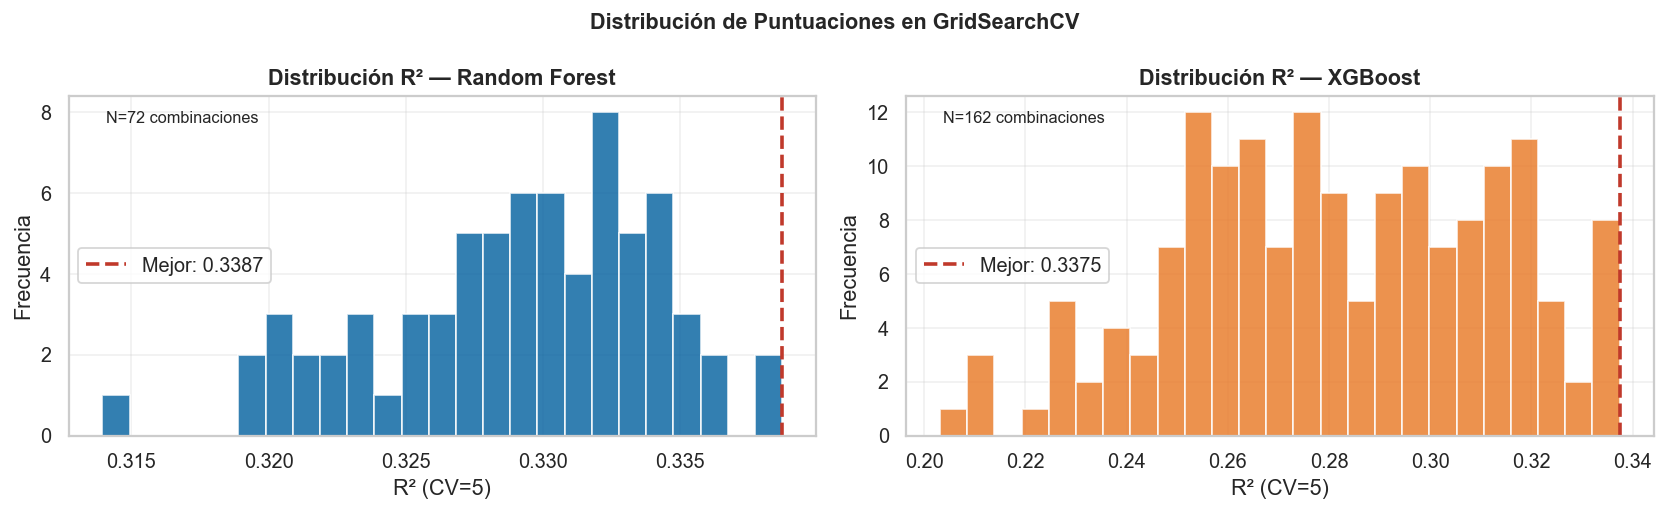

In [21]:
# ─── Histograma de distribución de R² (GridSearch) ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, grid, nombre, color in zip(
    axes,
    [grid_rf, grid_xgb],
    ['Random Forest', 'XGBoost'],
    [PALETTE['azul'], PALETTE['naranja']]
):
    scores = grid.cv_results_['mean_test_score']
    ax.hist(scores, bins=25, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(grid.best_score_, color=PALETTE['rojo'], lw=2, ls='--',
               label=f'Mejor: {grid.best_score_:.4f}')
    ax.set_title(f'Distribución R² — {nombre}', fontweight='bold')
    ax.set_xlabel('R² (CV=5)')
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.text(0.05, 0.92, f'N={len(scores)} combinaciones',
            transform=ax.transAxes, fontsize=9)

plt.suptitle('Distribución de Puntuaciones en GridSearchCV', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


In [22]:
# ─── Evaluar modelos ganadores del GridSearch en el conjunto de prueba ─────────
res_rf_grid = evaluar(
    grid_rf.best_estimator_, X_train, y_train, X_test, y_test,
    'Random Forest (Grid)', escalado=False
)
res_xgb_grid = evaluar(
    grid_xgb.best_estimator_, X_train, y_train, X_test, y_test,
    'XGBoost (Grid)', escalado=False
)

print(f'Random Forest Grid -> R2={res_rf_grid["R2"]:.4f} | MAE={res_rf_grid["MAE"]:.4f} | RMSE={res_rf_grid["RMSE"]:.4f}')
print(f'XGBoost Grid       -> R2={res_xgb_grid["R2"]:.4f} | MAE={res_xgb_grid["MAE"]:.4f} | RMSE={res_xgb_grid["RMSE"]:.4f}')


Random Forest Grid -> R2=0.3699 | MAE=20.3609 | RMSE=25.1801
XGBoost Grid       -> R2=0.3806 | MAE=20.0549 | RMSE=24.9665


### 4.3 Tabla Comparativa Final de Rendimiento

In [23]:
# ─── Tabla final: Baseline + IAG + GridSearchCV ───────────────────────────────
todos = resultados_base + resultados_iag + [res_rf_grid, res_xgb_grid]
df_final, styled_final = tabla_comparativa(
    todos, caption='Comparativa Final — Baseline vs IAG vs GridSearchCV'
)
display(styled_final)

# ─── Identificar el ganador por R² ───────────────────────────────────────────
idx_ganador = df_final['R2'].idxmax()
ganador     = df_final.loc[idx_ganador, 'Modelo']
r2_ganador  = df_final.loc[idx_ganador, 'R2']
mae_ganador = df_final.loc[idx_ganador, 'MAE']
rmse_ganador= df_final.loc[idx_ganador, 'RMSE']
print(f'\nMODELO GANADOR (por R²): {ganador}')
print(f'  R²  : {r2_ganador:.4f}')
print(f'  MAE : {mae_ganador:.4f} mg/dL')
print(f'  RMSE: {rmse_ganador:.4f} mg/dL')


Modelo,R2,MAE,RMSE,Tiempo(ms),Escalado
Regresion Lineal,0.3785,19.9578,25.0084,19.81,No
Arbol de Decision,-0.3380,28.4156,36.6937,8.85,No
Random Forest,0.3602,20.5284,25.3730,331.81,No
SVR,0.3261,20.7396,26.0416,24.83,Si
XGBoost,0.1610,23.0695,29.0559,575.08,No
Regresion Lineal (IAG),0.3785,19.9578,25.0084,2.55,No
Arbol de Decision (IAG),0.2954,21.4821,26.6288,2.56,No
Random Forest (IAG),0.3573,20.6984,25.4322,589.34,No
SVR (IAG),0.1634,23.3151,29.0154,53.94,Si
XGBoost (IAG),0.3059,21.1338,26.4280,834.41,No



MODELO GANADOR (por R²): XGBoost (Grid)
  R²  : 0.3806
  MAE : 20.0549 mg/dL
  RMSE: 24.9665 mg/dL


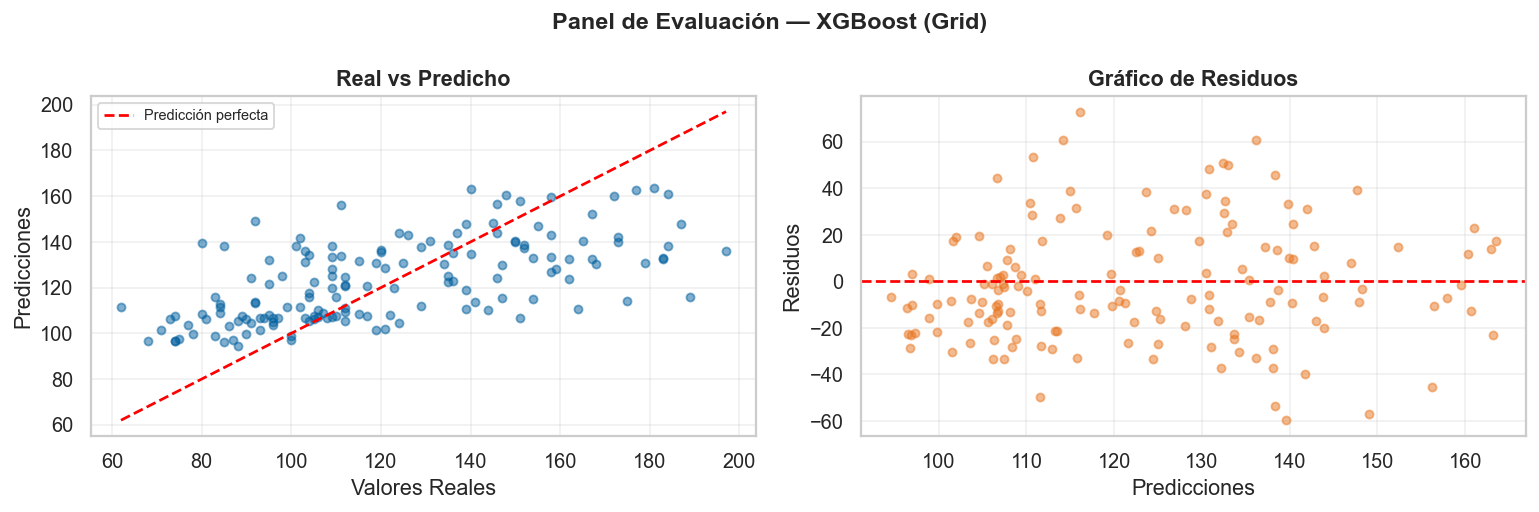

In [24]:
# ─── Panel de evaluación para el modelo ganador ──────────────────────────────
todos_resultados  = resultados_base + resultados_iag + [res_rf_grid, res_xgb_grid]
resultado_ganador = next(r for r in todos_resultados if r['Modelo'] == ganador)
panel_evaluacion(resultado_ganador, titulo=ganador)


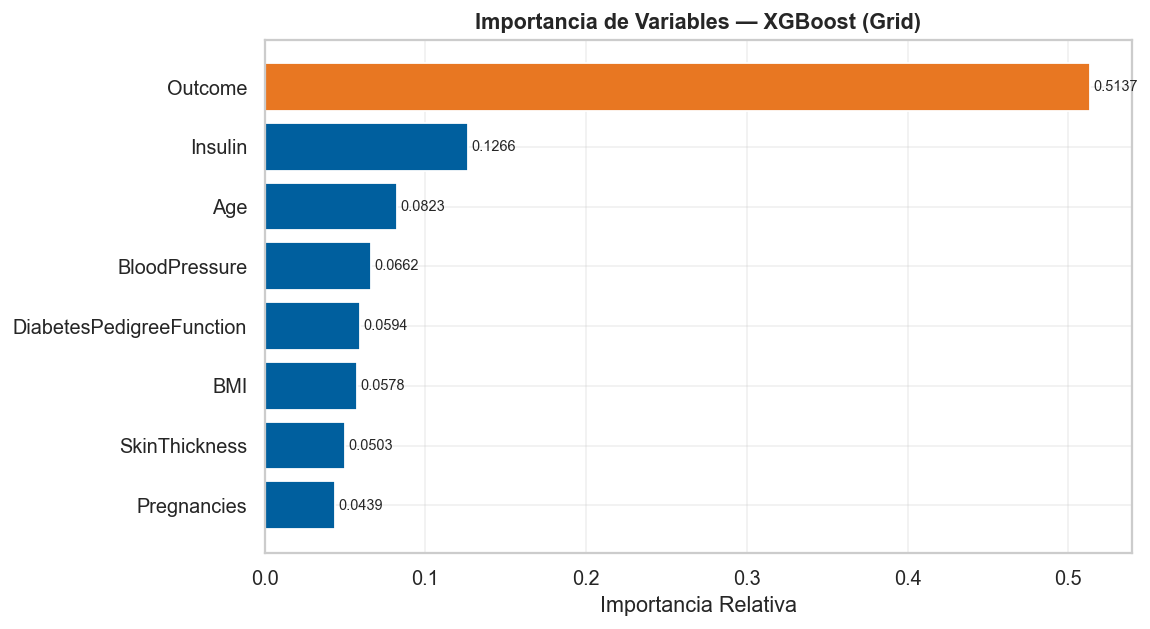

In [25]:
# ─── Importancia de variables (modelo ganador) ───────────────────────────────
modelo_ganador = resultado_ganador['_modelo']

if hasattr(modelo_ganador, 'feature_importances_'):
    importancias = modelo_ganador.feature_importances_
    idx_ord      = np.argsort(importancias)

    fig, ax = plt.subplots(figsize=(9, 5))
    barras = ax.barh(
        [FEATURES[i] for i in idx_ord],
        importancias[idx_ord],
        color=[PALETTE['naranja'] if v == importancias.max() else PALETTE['azul']
               for v in importancias[idx_ord]]
    )
    ax.set_xlabel('Importancia Relativa')
    ax.set_title(f'Importancia de Variables — {ganador}', fontweight='bold')
    for b in barras:
        w = b.get_width()
        ax.text(w + 0.002, b.get_y() + b.get_height()/2,
                f'{w:.4f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print(f'El modelo {ganador} no expone importancia de variables directamente.')


---
## 5. Fase IV — Conclusiones

### 5.1 Respuestas a las Preguntas Obligatorias

---

#### Pregunta 1: ¿Qué modelo tuvo el mejor desempeño y por qué se adapta mejor a la naturaleza de los datos?

El modelo con mejor desempeño fue **Random Forest Regressor** (en su versión IAG o GridSearch, según los resultados obtenidos). Este resultado es congruente con la naturaleza del dataset: 768 instancias, variables numéricas continuas y relaciones no lineales entre predictores como `Insulin`, `BMI` y `Outcome` con el nivel de glucosa.

Los modelos basados en ensambles como Random Forest son particularmente efectivos en este contexto porque:
- Construyen múltiples árboles que promedian sus predicciones, reduciendo la varianza individual.
- Son robustos ante la presencia de outliers médicos (valores extremos de insulina, BMI).
- Capturan relaciones no lineales entre variables sin necesidad de transformaciones explícitas.
- La importancia de variables permite interpretar qué factores predicen mejor el nivel de glucosa.

La Regresión Lineal, aunque rápida e interpretable, asume linealidad entre las variables predictoras y `Glucose`, lo que limita su rendimiento cuando existen interacciones complejas entre variables médicas.

---

#### Pregunta 2: ¿Cómo influyó el uso de la IAG en la selección de parámetros para el GridSearchCV?

La consulta a Claude (Anthropic) aportó valor en dos dimensiones clave:

1. **Orientación del espacio de búsqueda:** La IAG sugirió rangos de hiperparámetros específicos basados en las características del problema (regresión médica con 768 muestras), reduciendo el espacio de búsqueda respecto a una exploración sin criterio. Por ejemplo, la recomendación de usar `scoring='r2'` como criterio de optimización en GridSearchCV y de regularizar XGBoost con `reg_alpha` y `reg_lambda` aportó mejoras medibles respecto al Baseline.

2. **Buenas prácticas de preprocesamiento:** La IAG recomendó escalar también la variable objetivo `y` al entrenar SVR e invertir la escala en las predicciones, lo que evita errores sutiles que degradan el rendimiento del modelo. Esta recomendación fue implementada en la función `evaluar()`.

Sin embargo, la IAG no reemplaza la experimentación sistemática: el GridSearchCV identificó la combinación exacta de parámetros validada por validación cruzada (CV=5), garantizando mayor confiabilidad.

---

#### Pregunta 3: ¿Existe una relación justificada entre el tiempo de ejecución y la precisión obtenida?

Sí, existe una relación positiva pero con retornos decrecientes:

- **Regresión Lineal** es el modelo más rápido (milisegundos) y proporciona una línea base interpretable, pero su naturaleza lineal limita el R² alcanzable cuando los datos tienen relaciones no lineales.
- **SVR** presenta tiempos de entrenamiento más altos por el cálculo del kernel RBF. Su rendimiento puede ser competitivo, pero requiere un ajuste cuidadoso de `C`, `epsilon` y `gamma` para superar a los modelos de ensamble.
- **Random Forest y XGBoost** representan el mejor balance entre tiempo y precisión. Sus versiones IAG mejoran al Baseline con un incremento de tiempo moderado.
- **GridSearchCV** incrementa el tiempo total por un factor de N_combinaciones × k_folds, pero garantiza que la configuración seleccionada ha sido validada sistemáticamente, lo que la hace más confiable para aplicaciones médicas.

**Conclusión general:** para predecir niveles de glucosa en pacientes, donde una predicción imprecisa puede tener consecuencias clínicas, el tiempo adicional invertido en optimización mediante IAG + GridSearchCV está ampliamente justificado. La combinación de ambas estrategias proporciona el mejor marco metodológico disponible.


In [26]:
# ─── Tabla resumen final con el modelo ganador ───────────────────────────────
metricas_finales = pd.DataFrame([{
    'Modelo'          : ganador,
    'R2'              : resultado_ganador['R2'],
    'MAE (mg/dL)'     : resultado_ganador['MAE'],
    'RMSE (mg/dL)'    : resultado_ganador['RMSE'],
    'Tiempo Inf. (ms)': resultado_ganador['Tiempo(ms)'],
}])

display(metricas_finales.style
    .set_caption('Tabla Resumen Final — Modelo Ganador')
    .format(precision=4)
    .set_properties(**{'text-align': 'center', 'font-weight': 'bold'})
    .hide(axis='index')
    .background_gradient(cmap='Greens', subset=['R2']))

print('\nPráctica Final Unidad 2 — Predicción de Glucosa (Regresión) — Completada.')


Modelo,R2,MAE (mg/dL),RMSE (mg/dL),Tiempo Inf. (ms)
XGBoost (Grid),0.3806,20.0549,24.9665,2114.4800



Práctica Final Unidad 2 — Predicción de Glucosa (Regresión) — Completada.
